# 📊 Sales Data Analyzer Project (Pandas + NumPy)
# --------------------------------------------------
## This project analyzes an e-commerce dataset to extract business insights
## such as revenue trends, top products, customer behavior, and regional performance.

# 1. Load Dataset

In [2]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv('global_ecommerce_sales.csv')

In [4]:
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [5]:
df.shape

(2000, 15)

## 2. Initial Data Exploration

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


In [8]:
df.describe()

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
std,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593
min,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000


In [9]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

## 3. Data Cleaning

In [10]:
 df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [11]:
df.drop_duplicates()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ORD-10823,2025-12-31,Linda Nilsson,Consumer,France,Europe,Furniture,Folding Table Portable,5,104.73,0,523.65,19.10,190.36,PayPal
1996,ORD-10896,2025-12-31,Ayumi Dubois,Consumer,France,Europe,Clothing & Accessories,Cotton Formal Shirt,11,59.27,5,619.37,20.94,272.44,PayPal
1997,ORD-11148,2025-12-31,Barbara Jones,Consumer,Spain,Europe,Technology,Webcam HD 1080p,6,31.79,15,162.13,15.19,42.03,Bank Transfer
1998,ORD-11519,2025-12-31,Maria Suzuki,Home Office,Spain,Europe,Clothing & Accessories,Sports Water Bottle 750ml,5,9.50,5,45.12,14.25,7.12,Credit Card


In [12]:
df[['Unit_Price', 'Quantity', 'Discount_Percent','Total_Sales', 'Shipping_Cost','Profit']].dtypes

Unit_Price          float64
Quantity              int64
Discount_Percent      int64
Total_Sales         float64
Shipping_Cost       float64
Profit              float64
dtype: object

## 4. Feature Engineering

In [13]:
df['Month'] = df['Order_Date'].dt.month_name()
df['DayOfWeek'] = df['Order_Date'].dt.day_name()

In [14]:
def value(val):
    if val < 100:
        return "low"
    elif 100 <= val <= 500:
        return "Medium"
    else:
        return "High"

In [15]:
df['Order_Value_Category'] = df['Total_Sales'].apply(value)

## 5. Dataset Filtering

In [16]:
df[df["Total_Sales"] > 500]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method,Month,DayOfWeek,Order_Value_Category
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,January,Thursday,High
8,ORD-11702,2023-01-06,Thomas Smith,Consumer,China,Asia Pacific,Furniture,Standing Desk Converter,2,334.11,5,634.81,11.92,221.96,Bank Transfer,January,Friday,High
16,ORD-11886,2023-01-13,Christopher Johansson,Consumer,Nigeria,Middle East & Africa,Furniture,Corner L-Shaped Desk,3,358.60,15,914.43,14.74,254.21,Cash on Delivery,January,Friday,High
17,ORD-10339,2023-01-14,Susan Davis,Home Office,Australia,Asia Pacific,Furniture,Ergonomic Office Chair,2,446.80,5,848.92,13.59,299.17,Cash on Delivery,January,Saturday,High
18,ORD-10402,2023-01-14,Jamal Schmidt,Consumer,Mexico,North America,Furniture,Folding Table Portable,6,96.58,0,579.48,10.22,221.57,Credit Card,January,Saturday,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,ORD-10760,2025-12-15,Marco Taylor,Consumer,South Africa,Middle East & Africa,Furniture,Filing Cabinet 3-Drawer,3,242.14,15,617.46,15.04,166.57,Bank Transfer,December,Monday,High
1970,ORD-11342,2025-12-16,Nadia Nilsson,Corporate,South Korea,Asia Pacific,Furniture,Bookshelf 5-Tier,5,183.87,10,827.42,14.56,261.25,Cash on Delivery,December,Tuesday,High
1992,ORD-10188,2025-12-30,Elizabeth Müller,Home Office,Italy,Europe,Furniture,Mesh Back Task Chair,5,204.17,5,969.81,18.46,338.84,PayPal,December,Tuesday,High
1995,ORD-10823,2025-12-31,Linda Nilsson,Consumer,France,Europe,Furniture,Folding Table Portable,5,104.73,0,523.65,19.10,190.36,PayPal,December,Wednesday,High


In [17]:
df[df['Region'] == 'Europe']

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method,Month,DayOfWeek,Order_Value_Category
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery,January,Monday,Medium
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal,January,Tuesday,Medium
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,January,Thursday,High
11,ORD-11499,2023-01-08,Kenji Rossi,Corporate,Spain,Europe,Office Supplies,Paper Clips Box 500pc,3,7.80,10,21.06,12.61,-2.08,Cash on Delivery,January,Sunday,low
12,ORD-10271,2023-01-09,Mary Khan,Corporate,United Kingdom,Europe,Technology,Webcam HD 1080p,1,48.73,10,43.86,8.11,8.95,Credit Card,January,Monday,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992,ORD-10188,2025-12-30,Elizabeth Müller,Home Office,Italy,Europe,Furniture,Mesh Back Task Chair,5,204.17,5,969.81,18.46,338.84,PayPal,December,Tuesday,High
1995,ORD-10823,2025-12-31,Linda Nilsson,Consumer,France,Europe,Furniture,Folding Table Portable,5,104.73,0,523.65,19.10,190.36,PayPal,December,Wednesday,High
1996,ORD-10896,2025-12-31,Ayumi Dubois,Consumer,France,Europe,Clothing & Accessories,Cotton Formal Shirt,11,59.27,5,619.37,20.94,272.44,PayPal,December,Wednesday,High
1997,ORD-11148,2025-12-31,Barbara Jones,Consumer,Spain,Europe,Technology,Webcam HD 1080p,6,31.79,15,162.13,15.19,42.03,Bank Transfer,December,Wednesday,Medium


In [18]:
df[df['Product_Category'] == 'Furniture']

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method,Month,DayOfWeek,Order_Value_Category
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,January,Thursday,High
5,ORD-11746,2023-01-05,Fatima Suzuki,Consumer,Mexico,North America,Furniture,Bookshelf 5-Tier,1,61.93,10,55.74,5.88,12.70,PayPal,January,Thursday,low
8,ORD-11702,2023-01-06,Thomas Smith,Consumer,China,Asia Pacific,Furniture,Standing Desk Converter,2,334.11,5,634.81,11.92,221.96,Bank Transfer,January,Friday,High
9,ORD-10847,2023-01-07,Ali Rodriguez,Consumer,Saudi Arabia,Middle East & Africa,Furniture,Folding Table Portable,1,58.77,5,55.83,12.03,8.54,Credit Card,January,Saturday,low
16,ORD-11886,2023-01-13,Christopher Johansson,Consumer,Nigeria,Middle East & Africa,Furniture,Corner L-Shaped Desk,3,358.60,15,914.43,14.74,254.21,Cash on Delivery,January,Friday,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,ORD-10077,2025-12-23,Carlos Thomas,Consumer,France,Europe,Furniture,Monitor Riser Wood,2,70.68,15,120.16,9.93,25.41,Bank Transfer,December,Tuesday,Medium
1991,ORD-10675,2025-12-29,Sophie Clark,Consumer,Argentina,South America,Furniture,Folding Table Portable,2,84.14,20,134.62,14.99,18.66,PayPal,December,Monday,Medium
1992,ORD-10188,2025-12-30,Elizabeth Müller,Home Office,Italy,Europe,Furniture,Mesh Back Task Chair,5,204.17,5,969.81,18.46,338.84,PayPal,December,Tuesday,High
1994,ORD-11814,2025-12-30,Jennifer Oliveira,Consumer,India,Asia Pacific,Furniture,Filing Cabinet 3-Drawer,1,177.90,10,160.11,10.23,43.14,PayPal,December,Tuesday,Medium


## 6. Revenue Analysis

In [19]:
totalR = df['Total_Sales'].sum()
averageR = df['Total_Sales'].mean()
maxR = df['Total_Sales'].max()
minR = df['Total_Sales'].min()
totalR,averageR,maxR,minR

(np.float64(484559.33999999997), np.float64(242.27966999999998), 3813.98, 2.42)

## 7. Product Performance Analysis

In [20]:
top_10_revenue = df.groupby('Product_Name')['Total_Sales'].sum().sort_values(ascending=False).head(10)
top_10_revenue

Product_Name
Standing Desk Converter          46614.22
Ergonomic Office Chair           45405.15
Corner L-Shaped Desk             41070.48
Mesh Back Task Chair             38179.77
Wireless Bluetooth Headphones    28258.70
Mechanical Gaming Keyboard       24072.42
Filing Cabinet 3-Drawer          23108.01
Folding Table Portable           18663.13
Portable External SSD 1TB        18065.30
Bookshelf 5-Tier                 17741.59
Name: Total_Sales, dtype: float64

In [21]:
most_sold_products = df.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False).head(10)
most_sold_products

Product_Name
Wireless Ergonomic Mouse         238
Mechanical Gaming Keyboard       227
Folding Table Portable           226
Tablet Stand Holder              225
Smart LED Desk Lamp              222
Desk Calendar 2025               218
Standing Desk Converter          215
Mesh Back Task Chair             213
Wireless Bluetooth Headphones    212
Stapler Full-Size                211
Name: Quantity, dtype: int64

In [22]:
least_performing_products = df.groupby('Product_Name')['Total_Sales'].sum().sort_values(ascending=True).head(10)
least_performing_products

Product_Name
Paper Clips Box 500pc              901.89
Highlighters Neon Pack 6           942.61
Sticky Notes Multicolor 6-Pack    1072.27
Ballpoint Pen Pack 12             1760.36
Binder Clips Assorted 48pc        1924.59
Whiteboard Markers Set 8          2090.67
Silk Tie Collection               2307.23
Desk Calendar 2025                2481.21
Premium Notebook Set A5           2536.17
Stapler Full-Size                 2622.15
Name: Total_Sales, dtype: float64

## 8. Customer Analysis

In [23]:
total_spending = df.groupby('Customer_Name')['Total_Sales'].agg(['sum', 'mean', 'count'])
total_spending

,sum,mean,count
Customer_Name,,,
Ahmed Ali,509.12,509.120000,1
Ahmed Anderson,133.68,133.680000,1
Ahmed Clark,94.28,47.140000,2
Ahmed Dubois,105.73,35.243333,3
Ahmed Garcia,1769.48,884.740000,2
...,...,...,...
Zara Thomas,95.53,95.530000,1
Zara Wang,25.37,25.370000,1
Zara Weber,47.46,47.460000,1


In [24]:
top5_customer = total_spending.sort_values(by='sum', ascending=False).head()
top5_customer

,sum,mean,count
Customer_Name,,,
Priya Jackson,3836.46,1918.230000,2
Hanna Jones,3813.98,3813.980000,1
Sarah Chen,3184.56,1592.280000,2
Li Laurent,3007.62,3007.620000,1
Nadia Wang,2958.97,986.323333,3


In [25]:
average_spending = total_spending['sum'].mean()
average_spending

np.float64(315.8796219035202)

## 9. Regional Sales Analysis

In [26]:
Region_revenue = df.groupby('Region').agg({
    'Total_Sales': 'sum',
    'Quantity': 'sum'
})
Region_revenue

,Total_Sales,Quantity
Region,,
Asia Pacific,121707.51,1909
Europe,137006.20,1822
Middle East & Africa,45918.12,730
North America,133876.38,1996
South America,46051.13,658


In [27]:
HighestRR = Region_revenue.sort_values(by='Total_Sales', ascending=False).head(1)
HighestRR

,Total_Sales,Quantity
Region,,
Europe,137006.2,1822


## 10. Category Analysis

In [28]:
categoryAnalysis = df.groupby('Product_Category')['Total_Sales'].agg(['sum', 'mean'])
categoryAnalysis

,sum,mean
Product_Category,,
Clothing & Accessories,69375.63,167.979734
Furniture,256274.68,505.472742
Office Supplies,19390.81,37.798850
Technology,139518.22,246.063880


In [29]:
popularProduct = df['Product_Category'].value_counts().idxmax()
popularProduct

'Technology'

## 11. Time Based Analysis

In [30]:
monthlySales = df.groupby('Month')['Total_Sales'].sum()
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthlySales = monthlySales.reindex(month_order)
monthlySales

Month
January      31611.59
February     36260.55
March        34378.89
April        44203.66
May          42434.47
June         43694.85
July         45671.22
August       34157.01
September    36002.05
October      51095.40
November     39669.78
December     45379.87
Name: Total_Sales, dtype: float64

In [31]:
weekdaysAnalysis = df.groupby('DayOfWeek')['Total_Sales'].sum()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekdaysAnalysis = weekdaysAnalysis.reindex(days)
weekdaysAnalysis

DayOfWeek
Monday       62854.94
Tuesday      69075.22
Wednesday    69013.49
Thursday     69752.69
Friday       64637.76
Saturday     74438.71
Sunday       74786.53
Name: Total_Sales, dtype: float64

In [32]:
best_month = monthlySales.idxmax()
best_month_sales = monthlySales.max()

print("Best Month:", best_month)
print("Sales:", best_month_sales)

Best Month: October
Sales: 51095.4


<Axes: xlabel='Month'>

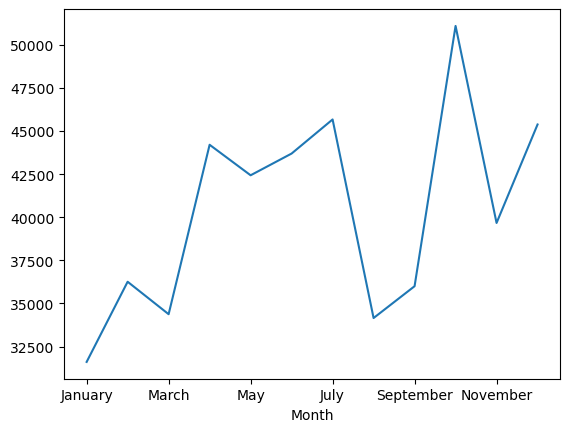

In [33]:
monthlySales.plot(kind = 'line')

## 12. Pivot Table Analysis

In [34]:
R_vs_C = df.pivot_table(values='Total_Sales',
               index='Region',aggfunc='sum',columns='Product_Category')
R_vs_C

Product_Category,Clothing & Accessories,Furniture,Office Supplies,Technology
Region,,,,
Asia Pacific,17185.71,63448.33,6082.59,34990.88
Europe,19138.88,77277.40,3702.84,36887.08
Middle East & Africa,7161.71,21475.34,1795.40,15485.67
North America,18124.54,73499.85,5837.17,36414.82
South America,7764.79,20573.76,1972.81,15739.77


In [35]:
M_vs_C = df.pivot_table(values='Total_Sales',
               index='Month',aggfunc='sum',columns='Product_Category')
M_vs_C = M_vs_C.reindex(month_order)
M_vs_C

Product_Category,Clothing & Accessories,Furniture,Office Supplies,Technology
Month,,,,
January,3225.77,18071.59,1578.16,8736.07
February,6613.46,19064.56,752.13,9830.40
March,4303.55,15223.97,1671.47,13179.90
April,5793.97,22334.59,1752.19,14322.91
May,6058.89,21978.87,1831.39,12565.32
June,3659.70,27226.51,1297.49,11511.15
July,5552.30,27533.04,1351.67,11234.21
August,7477.86,9943.92,1652.40,15082.83
September,3955.40,18818.93,1848.55,11379.17


## 13. NumPy Statistical Analysis

In [36]:
mean_revenue = np.mean(df['Total_Sales'])

std_revenue = np.std(df['Total_Sales'])

median_revenue = np.median(df['Total_Sales'])

percentile_25 = np.percentile(df['Total_Sales'], 25)

percentile_75 = np.percentile(df['Total_Sales'], 75)

print(mean_revenue)
print(std_revenue)
print(median_revenue)
print(percentile_25)
print(percentile_75)

242.27966999999998
382.4881443250122
113.125
41.2275
266.5525


## 14. Outlier Detection

In [39]:
IQR = percentile_75 - percentile_25

outliers = df[(df['Total_Sales'] < (Q1 - 1.5 * IQR)) | 
              (df['Total_Sales'] > (Q3 + 1.5 * IQR))]

outliers

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method,Month,DayOfWeek,Order_Value_Category
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,January,Thursday,High
8,ORD-11702,2023-01-06,Thomas Smith,Consumer,China,Asia Pacific,Furniture,Standing Desk Converter,2,334.11,5,634.81,11.92,221.96,Bank Transfer,January,Friday,High
16,ORD-11886,2023-01-13,Christopher Johansson,Consumer,Nigeria,Middle East & Africa,Furniture,Corner L-Shaped Desk,3,358.60,15,914.43,14.74,254.21,Cash on Delivery,January,Friday,High
17,ORD-10339,2023-01-14,Susan Davis,Home Office,Australia,Asia Pacific,Furniture,Ergonomic Office Chair,2,446.80,5,848.92,13.59,299.17,Cash on Delivery,January,Saturday,High
24,ORD-11128,2023-01-18,Amir Oliveira,Consumer,Mexico,North America,Furniture,Standing Desk Converter,5,333.59,10,1501.15,9.02,491.36,Credit Card,January,Wednesday,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1957,ORD-10272,2025-12-09,Jennifer Clark,Home Office,Spain,Europe,Furniture,Bookshelf 5-Tier,7,107.98,5,718.07,13.14,251.41,Cash on Delivery,December,Tuesday,High
1966,ORD-10760,2025-12-15,Marco Taylor,Consumer,South Africa,Middle East & Africa,Furniture,Filing Cabinet 3-Drawer,3,242.14,15,617.46,15.04,166.57,Bank Transfer,December,Monday,High
1970,ORD-11342,2025-12-16,Nadia Nilsson,Corporate,South Korea,Asia Pacific,Furniture,Bookshelf 5-Tier,5,183.87,10,827.42,14.56,261.25,Cash on Delivery,December,Tuesday,High
1992,ORD-10188,2025-12-30,Elizabeth Müller,Home Office,Italy,Europe,Furniture,Mesh Back Task Chair,5,204.17,5,969.81,18.46,338.84,PayPal,December,Tuesday,High


## 15. Summary

In [42]:
summary = df.describe()

,Order_Date,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,2024-07-12 03:17:16.800000,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
min,2023-01-02 00:00:00,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2023-10-08 00:00:00,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,2024-07-12 12:00:00,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,2025-04-20 06:00:00,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,2025-12-31 00:00:00,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000
std,NaN,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593


## 16. Exporting into File

In [43]:
df.to_csv("cleaned_sales_data.csv", index=False)